## MLP Model Visualizations

### Imports and Setup

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import torch
import torch.nn as nn
import io
import pickle

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load 5-Fold Cross-Validation Data

In [3]:
# Function to load the KFold = 5 normalized data
def load_kfold_data(fold):
    train = pd.read_csv(f'../dataset_generators/datasets/{fold}_train_normalized.csv')
    test = pd.read_csv(f'../dataset_generators/datasets/{fold}_test_normalized.csv')
    return train, test

### Load Best Model

In [4]:
# Load the best model(MLP)
class tanh_MLP(nn.Module):
    def __init__(self, input_size=100, hidden_size1=100, hidden_size2=100, output_size=1):
        super(tanh_MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        out = self.fc3(x)
        return out

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Custom unpickler to map CUDA tensors to appropriate device
class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location=device)
        else:
            return super().find_class(module, name)

with open('../model_generators/mlp/models/0_100-100_tanh_100_0.0001_norm.pickle', 'rb') as f:
    best_model = CPU_Unpickler(f).load()
    # Move model to CPU if it was trained on CUDA and wrapped in DataParallel
    if hasattr(best_model, 'module'):
        best_model = best_model.module
    best_model = best_model.to(device)
    best_model.eval()  # Set to evaluation mode

Using device: cpu


In [5]:
best_model

tanh_MLP(
  (fc1): Linear(in_features=66, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=1, bias=True)
)

In [6]:
rmse_list = []
r2_list = []
mae_list = []

# Function to perform cross-validation and evaluate best model(MLP)
def cross_validate_model():
    for fold in range(5):
        train, test = load_kfold_data(fold)
        X_train = train.iloc[:, 12:].drop(columns=['fantasy_points'])
        y_train = train['fantasy_points']
        X_test = test.iloc[:, 12:].drop(columns=['fantasy_points'])
        y_test = test['fantasy_points']
        
        # Use the pre-trained model for prediction
        with torch.no_grad():
            y_pred = best_model(torch.tensor(X_test.values, dtype=torch.float32)).numpy().flatten()
        
        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        print(f"Fold {fold}:")
        print("Root Mean Squared Error:", rmse)
        print("R^2 Score:", r2)
        print("Mean Absolute Error:", mae)
        rmse_list.append(rmse)
        r2_list.append(r2)
        mae_list.append(mae)
        
    # Concatenate all test sets
    all_test = pd.concat([load_kfold_data(fold)[1] for fold in range(5)], ignore_index=True)
    all_test = all_test.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')
    test = all_test
    X_test = test.iloc[:, 12:].drop(columns=['fantasy_points'])
    y_test = test['fantasy_points']

    # Concatenate all train sets
    all_train = pd.concat([load_kfold_data(fold)[0] for fold in range(5)], ignore_index=True)
    all_train = all_train.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')
    train = all_train
    X_train = train.iloc[:, 12:].drop(columns=['fantasy_points'])
    y_train = train['fantasy_points']

    print("\n")
    mean_rmse = np.mean(rmse_list)
    mean_r2 = np.mean(r2_list)
    mean_mae = np.mean(mae_list)
    
    std_rmse = np.std(rmse_list)
    std_r2 = np.std(r2_list)
    std_mae = np.std(mae_list)
    
    print("Mean RMSE across all folds:", mean_rmse)
    print("Standard Deviation of RMSE across all folds:", std_rmse)
    print("Mean R^2 Score across all folds:", mean_r2)
    print("Standard Deviation of R^2 Score across all folds:", std_r2)
    print("Mean MAE across all folds:", mean_mae)
    print("Standard Deviation of MAE across all folds:", std_mae)
    
    return best_model, X_train, y_train, X_test, y_test

model, X_train, y_train, X_test, y_test = cross_validate_model()

Fold 0:
Root Mean Squared Error: 5.373942625726363
R^2 Score: 0.40797980981353843
Mean Absolute Error: 3.8612903845807813
Fold 1:
Root Mean Squared Error: 5.408200136852504
R^2 Score: 0.4131191679594063
Mean Absolute Error: 3.8240117625190226
Fold 2:
Root Mean Squared Error: 5.443003462916148
R^2 Score: 0.4072353767698613
Mean Absolute Error: 4.011704739238129
Fold 3:
Root Mean Squared Error: 5.311074618297876
R^2 Score: 0.40903618152277454
Mean Absolute Error: 3.7432234428376607
Fold 4:
Root Mean Squared Error: 5.27032754539036
R^2 Score: 0.4121866227710438
Mean Absolute Error: 3.8043148471108643


Mean RMSE across all folds: 5.361309677836651
Standard Deviation of RMSE across all folds: 0.06298172857433389
Mean R^2 Score across all folds: 0.40991143176732486
Standard Deviation of R^2 Score across all folds: 0.002329144147268573
Mean MAE across all folds: 3.8489090352572917
Standard Deviation of MAE across all folds: 0.08992630237813391


In [7]:
# save the best model(MLP)
with open('../model_generators/mlp/models/best_mlp_model.pkl', 'wb') as f:
    pickle.dump(model, f)

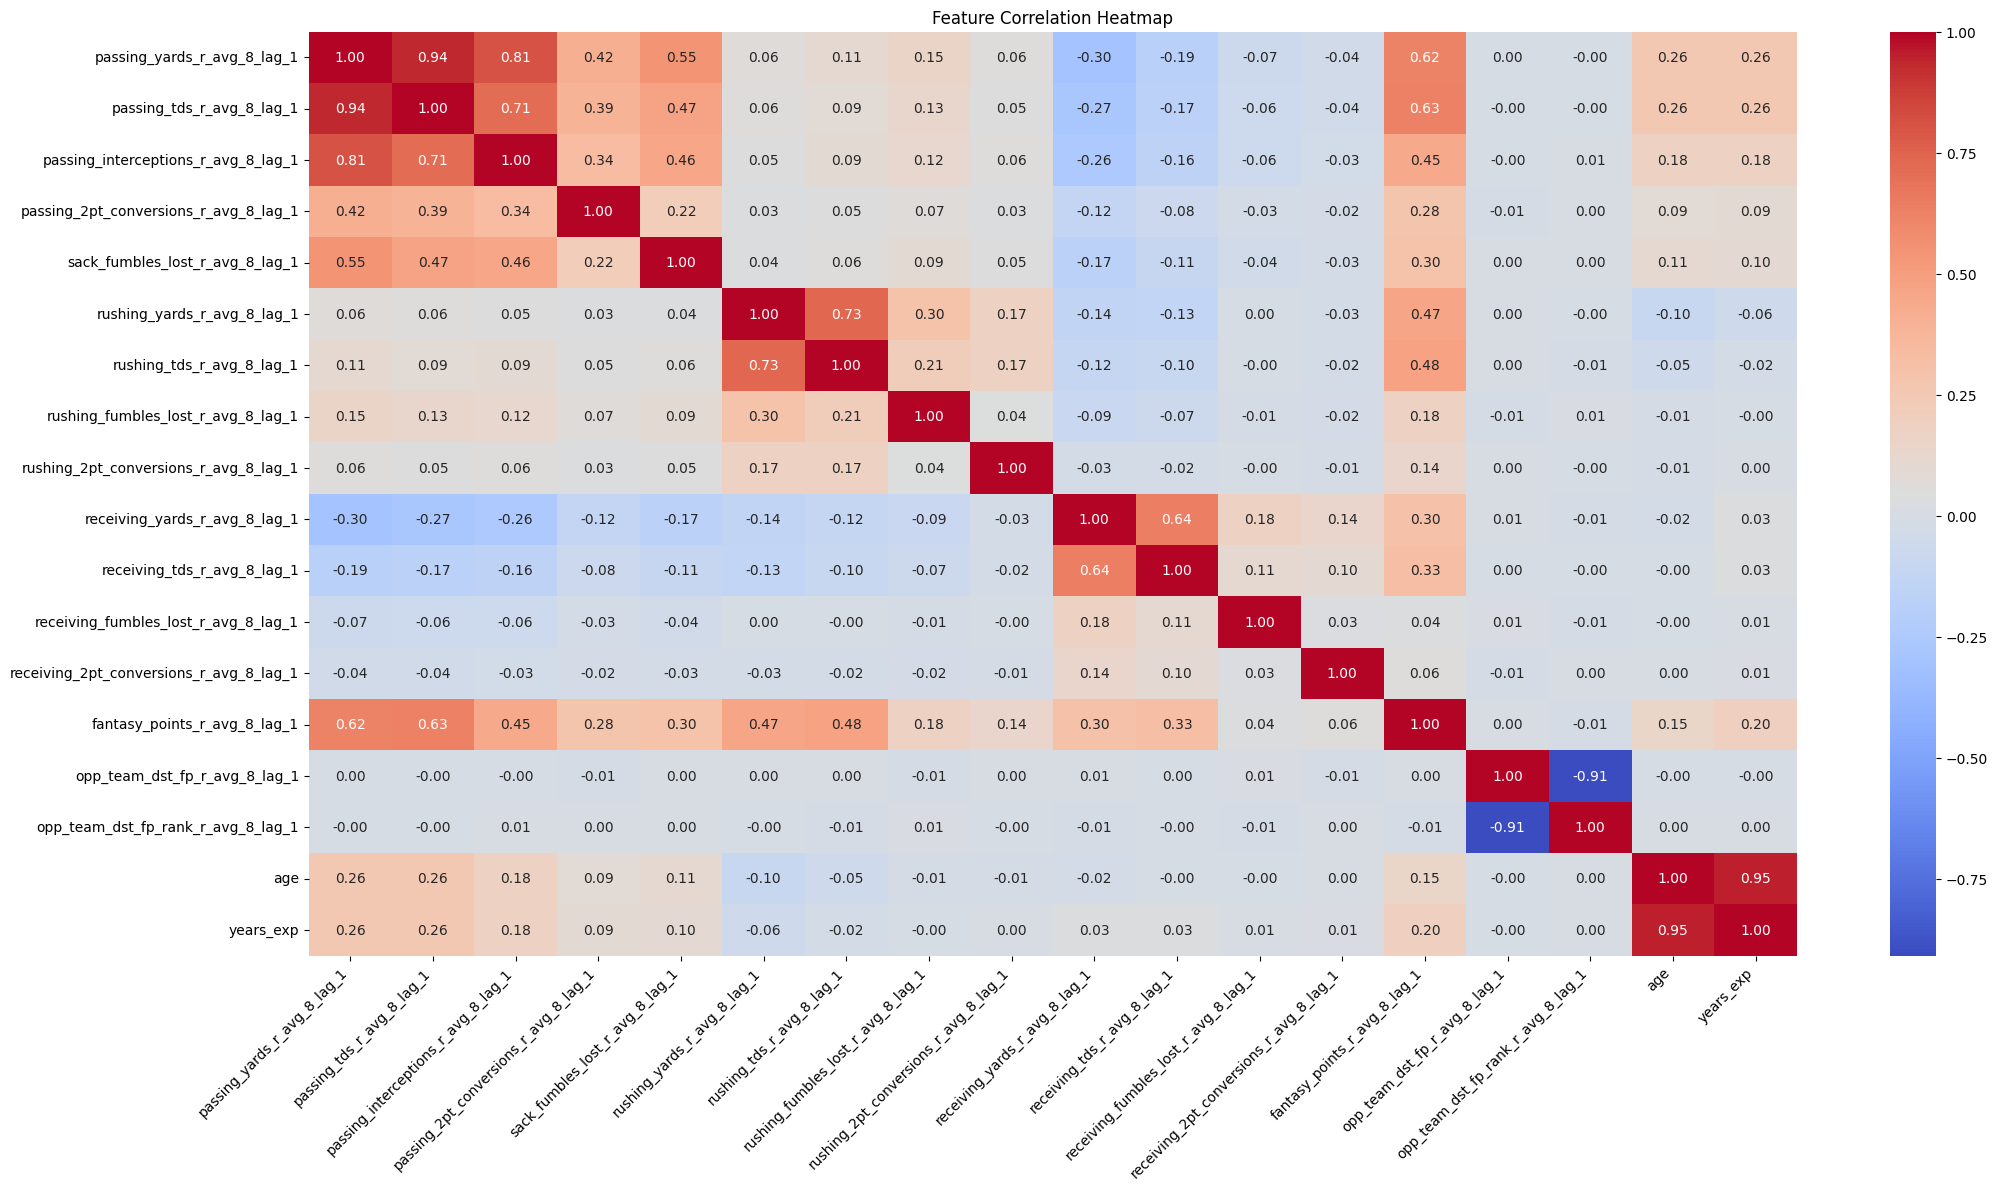

In [ ]:
# Plot Correlation Heatmap
def plot_correlation_heatmap(feature_names):
    feature_names = feature_names.tolist() if isinstance(feature_names, pd.Index) else feature_names
    # Ensure only feature names that currently end with '_8_lag_1' except 'age' and 'years_exp'
    selected_features = [name for name in feature_names if name.endswith('_8_lag_1')] + ['age', 'years_exp']
    X_selected = X_train[selected_features]
    
    # Create a correlation matrix and plot the heatmap
    plt.figure(figsize=(24, 12))
    corr = X_selected.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.xticks(rotation=45, ha='right')
    plt.title("Feature Correlation Heatmap")
    plt.savefig('../model_visualizations/feature_correlation_heatmap.png')
    plt.show()
    plt.close()

plot_correlation_heatmap(X_train.columns)


In [18]:
model

tanh_MLP(
  (fc1): Linear(in_features=66, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=1, bias=True)
)

Learning Rate: 0.0001, Mean MAE across folds: 5.348830552975685
Learning Rate: 0.0002, Mean MAE across folds: 4.804950997862514
Learning Rate: 0.0003, Mean MAE across folds: 4.9553317844212765
Learning Rate: 0.0004, Mean MAE across folds: 5.0859997560283485
Learning Rate: 0.0005, Mean MAE across folds: 5.0130217505596795
Learning Rate: 0.0006, Mean MAE across folds: 4.8655173336388255
Learning Rate: 0.0007, Mean MAE across folds: 4.7375467610579305
Learning Rate: 0.0008, Mean MAE across folds: 4.576160956055032
Learning Rate: 0.0009, Mean MAE across folds: 4.49585180976314
Learning Rate: 0.001, Mean MAE across folds: 4.240277576230041


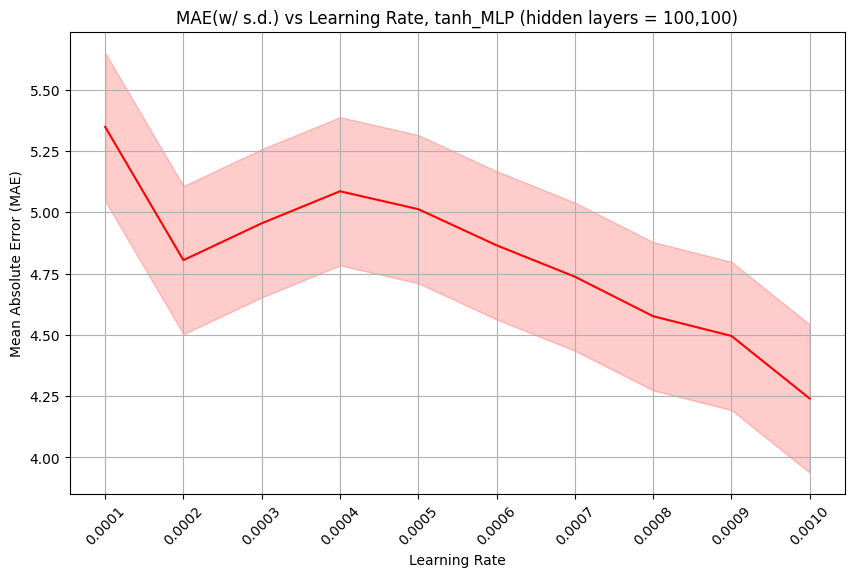

In [23]:
# Use the trained model to plot MAE against various learning rates with area of std deviation as shaded region
learning_rates = [0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.001]
def plot_mae_vs_learning_rate(learning_rates):
    mae_values = []
    for lr in learning_rates:
        fold_maes = []
        for fold in range(5):
            train, test = load_kfold_data(fold)
            X_train_fold = train.iloc[:, 12:].drop(columns=['fantasy_points'])
            y_train_fold = train['fantasy_points']
            X_test_fold = test.iloc[:, 12:].drop(columns=['fantasy_points'])
            y_test_fold = test['fantasy_points']

            pytorch_model = tanh_MLP(input_size=X_train_fold.shape[1], hidden_size1=100, hidden_size2=100, output_size=1).to(device)
            criterion = nn.MSELoss()
            optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=lr)

            X_train_tensor = torch.tensor(X_train_fold.values, dtype=torch.float32).to(device)
            y_train_tensor = torch.tensor(y_train_fold.values, dtype=torch.float32).view(-1, 1).to(device)
            X_test_tensor = torch.tensor(X_test_fold.values, dtype=torch.float32).to(device)
            y_test_tensor = torch.tensor(y_test_fold.values, dtype=torch.float32).view(-1, 1).to(device)

            pytorch_model.train()
            for epoch in range(100):
                optimizer.zero_grad()
                outputs = pytorch_model(X_train_tensor)
                loss = criterion(outputs, y_train_tensor)
                loss.backward()
                optimizer.step()

            pytorch_model.eval()
            with torch.no_grad():
                y_pred = pytorch_model(X_test_tensor).cpu().numpy().flatten()
            mae = mean_absolute_error(y_test_fold, y_pred)
            fold_maes.append(mae)
        mean_mae = np.mean(fold_maes)
        mae_values.append(mean_mae)
        print(f"Learning Rate: {lr}, Mean MAE across folds: {mean_mae}")

    mae_values_std = np.std(mae_values)
    plt.figure(figsize=(10, 6))
    plt.fill_between(learning_rates, np.array(mae_values) - mae_values_std, np.array(mae_values) + mae_values_std, alpha=0.2, color='r')
    plt.plot(learning_rates, mae_values, color='r')
    plt.xticks(learning_rates, rotation=45)
    plt.xlabel('Learning Rate')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.title('MAE(w/ s.d.) vs Learning Rate, tanh_MLP (hidden layers = 100,100)')
    plt.grid(True)
    plt.show()
    plt.savefig('mae_vs_learning_rate_pytorch.png')
    plt.close()

plot_mae_vs_learning_rate(learning_rates)

Fold 0, Hidden Layer Size: (50,), MAE: 5.734288353996236
Fold 1, Hidden Layer Size: (50,), MAE: 5.730260219609853
Fold 2, Hidden Layer Size: (50,), MAE: 5.76840354548657
Fold 3, Hidden Layer Size: (50,), MAE: 5.552167351933822
Fold 4, Hidden Layer Size: (50,), MAE: 5.685948676744997
Fold 0, Hidden Layer Size: (100,), MAE: 5.30775979663361
Fold 1, Hidden Layer Size: (100,), MAE: 5.4209285010618125
Fold 2, Hidden Layer Size: (100,), MAE: 5.418706326267456
Fold 3, Hidden Layer Size: (100,), MAE: 5.284257821029809
Fold 4, Hidden Layer Size: (100,), MAE: 5.229271248623315
Fold 0, Hidden Layer Size: (150,), MAE: 5.018872904084992
Fold 1, Hidden Layer Size: (150,), MAE: 5.057214376153331
Fold 2, Hidden Layer Size: (150,), MAE: 5.107209006381539
Fold 3, Hidden Layer Size: (150,), MAE: 4.960572353039333
Fold 4, Hidden Layer Size: (150,), MAE: 4.880039075481327
Fold 0, Hidden Layer Size: (100, 50), MAE: 5.442253501867297
Fold 1, Hidden Layer Size: (100, 50), MAE: 5.596393293039572
Fold 2, Hidden

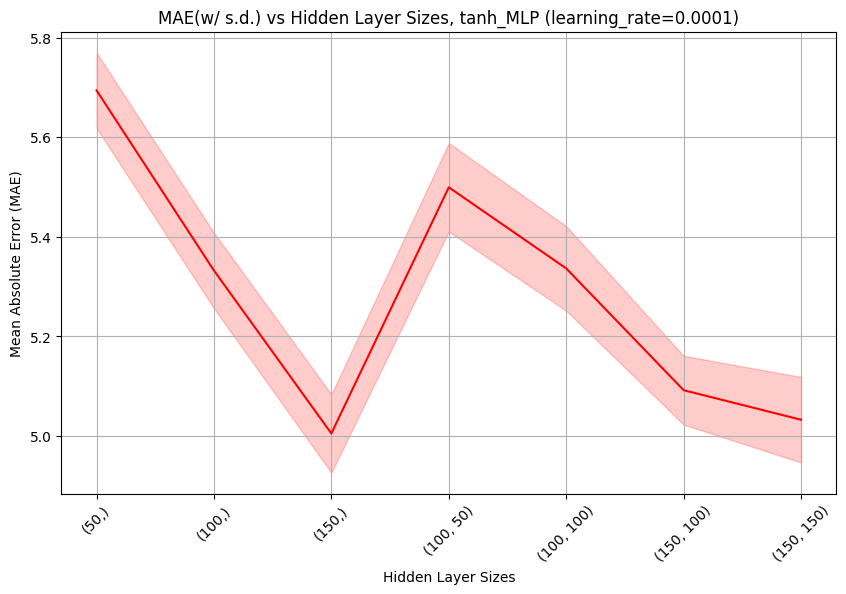

In [25]:
# Use the trained model to plot MAE against various hidden layer sizes with area of std deviation as shaded region
hidden_layer_sizes = [(50,), (100,), (150,), (100, 50), (100, 100), (150, 100), (150, 150)]
def plot_mae_vs_hidden_layers(hidden_layer_sizes):
    mean_mae_values = []
    std_mae_values = []
    for hls in hidden_layer_sizes:
        fold_maes = []
        for fold in range(5):
            train, test = load_kfold_data(fold)
            X_train_fold = train.iloc[:, 12:].drop(columns=['fantasy_points'])
            y_train_fold = train['fantasy_points']
            X_test_fold = test.iloc[:, 12:].drop(columns=['fantasy_points'])
            y_test_fold = test['fantasy_points']

            pytorch_model = tanh_MLP(
                input_size=X_train_fold.shape[1],
                hidden_size1=hls[0],
                hidden_size2=hls[1] if len(hls) > 1 else hls[0],
                output_size=1
            ).to(device)
            criterion = nn.MSELoss()
            optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=0.0001)
            X_train_tensor = torch.tensor(X_train_fold.values, dtype=torch.float32).to(device)
            y_train_tensor = torch.tensor(y_train_fold.values, dtype=torch.float32).view(-1, 1).to(device)
            X_test_tensor = torch.tensor(X_test_fold.values, dtype=torch.float32).to(device)
            y_test_tensor = torch.tensor(y_test_fold.values, dtype=torch.float32).view(-1, 1).to(device)
            
            pytorch_model.train()
            for epoch in range(100):
                optimizer.zero_grad()
                outputs = pytorch_model(X_train_tensor)
                loss = criterion(outputs, y_train_tensor)
                loss.backward()
                optimizer.step()
            
            pytorch_model.eval()
            with torch.no_grad():
                y_pred = pytorch_model(X_test_tensor).cpu().numpy().flatten()
            mae = mean_absolute_error(y_test_fold, y_pred)
            fold_maes.append(mae)
            print(f"Fold {fold}, Hidden Layer Size: {hls}, MAE: {mae}")
        mean_mae = np.mean(fold_maes)
        std_mae = np.std(fold_maes)
        mean_mae_values.append(mean_mae)
        std_mae_values.append(std_mae)

    x = range(len(hidden_layer_sizes))
    labels = [str(hls) for hls in hidden_layer_sizes]

    plt.figure(figsize=(10, 6))
    mean_mae_values = np.array(mean_mae_values)
    std_mae_values = np.array(std_mae_values)
    plt.fill_between(x, mean_mae_values - std_mae_values, mean_mae_values + std_mae_values, alpha=0.2, color='r')
    plt.plot(x, mean_mae_values, color='r')
    plt.xticks(x, labels, rotation=45)
    plt.xlabel('Hidden Layer Sizes')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.title('MAE(w/ s.d.) vs Hidden Layer Sizes, tanh_MLP (learning_rate=0.0001)')
    plt.grid(True)
    plt.show()
    plt.savefig('mae_vs_hidden_layer_sizes.png')
    plt.close()

plot_mae_vs_hidden_layers(hidden_layer_sizes)

In [13]:
# Function to use model to predict fantasy points for all weeks
def predict_fantasy_points(model):
    """
    Predict fantasy points for each player's next game using the trained model.
    
    Args:
        model: Trained MLP model
        
    Returns:
        numpy.array: Predicted fantasy points for each player
    """
    # Concatenate all test sets
    for fold in range(5):
        _, test = load_kfold_data(fold)
        if fold == 0:
            all_test = test
        else:
            all_test = pd.concat([all_test, test], ignore_index=True)
            
    test = all_test

    X_test = test.iloc[:, 12:].drop(columns=['fantasy_points'])

    # Make predictions with the trained MLP model
    model.eval()  # Ensure the model is in evaluation mode
    with torch.no_grad():
        predicted_fantasy_points = model(torch.tensor(X_test.values, dtype=torch.float32)).numpy().flatten()

        test['predicted_fantasy_points'] = predicted_fantasy_points

        return test[['player_id', 'player_name', 'position_group', 'team', 'season', 'week', 'fantasy_points', 'predicted_fantasy_points']]

# Predict fantasy points for next week using the last trained model
predicted_fantasy_points = predict_fantasy_points(model)
predicted_fantasy_points

,player_id,player_name,position_group,team,season,week,fantasy_points,predicted_fantasy_points
0,00-0007091,M.Hasselbeck,QB,IND,2015,5,16.22,16.094904
1,00-0007091,M.Hasselbeck,QB,IND,2015,12,20.30,14.151379
2,00-0007091,M.Hasselbeck,QB,IND,2015,13,4.86,15.724441
3,00-0010346,P.Manning,QB,DEN,2015,8,11.60,13.745428
4,00-0010346,P.Manning,QB,DEN,2015,10,-6.60,13.927474
...,...,...,...,...,...,...,...,...
60964,00-0039919,R.Odunze,WR,CHI,2024,6,4.00,6.150103
60965,00-0039919,R.Odunze,WR,CHI,2024,8,5.40,5.675765
60966,00-0039919,R.Odunze,WR,CHI,2024,13,2.50,6.145479
60967,00-0039919,R.Odunze,WR,CHI,2024,14,16.20,6.374872


In [14]:
# Remove duplicate rows where player_name, season, and week values are the same, keeping the first occurrence
predicted_fantasy_points = predicted_fantasy_points.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')

# Show the cleaned DataFrame
predicted_fantasy_points

,player_id,player_name,position_group,team,season,week,fantasy_points,predicted_fantasy_points
0,00-0007091,M.Hasselbeck,QB,IND,2015,5,16.22,16.094904
1,00-0007091,M.Hasselbeck,QB,IND,2015,12,20.30,14.151379
2,00-0007091,M.Hasselbeck,QB,IND,2015,13,4.86,15.724441
3,00-0010346,P.Manning,QB,DEN,2015,8,11.60,13.745428
4,00-0010346,P.Manning,QB,DEN,2015,10,-6.60,13.927474
...,...,...,...,...,...,...,...,...
60964,00-0039919,R.Odunze,WR,CHI,2024,6,4.00,6.150103
60965,00-0039919,R.Odunze,WR,CHI,2024,8,5.40,5.675765
60966,00-0039919,R.Odunze,WR,CHI,2024,13,2.50,6.145479
60967,00-0039919,R.Odunze,WR,CHI,2024,14,16.20,6.374872


In [ ]:
# Save the predictions to a CSV file
predicted_fantasy_points.to_csv('../predictions/mlp_predictions.csv', index=False)

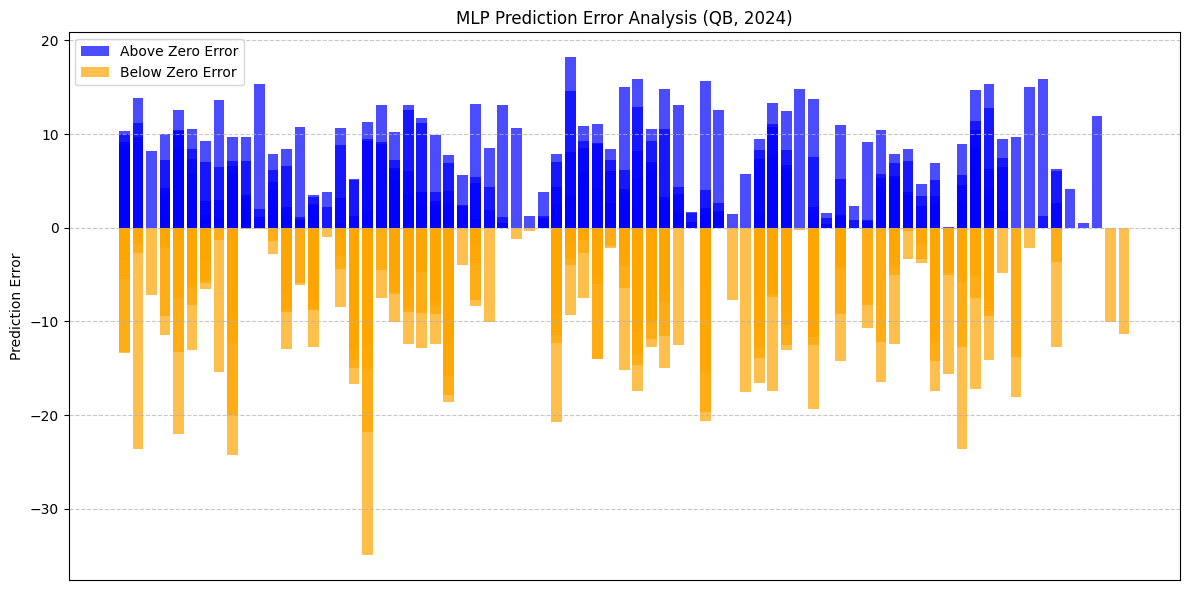

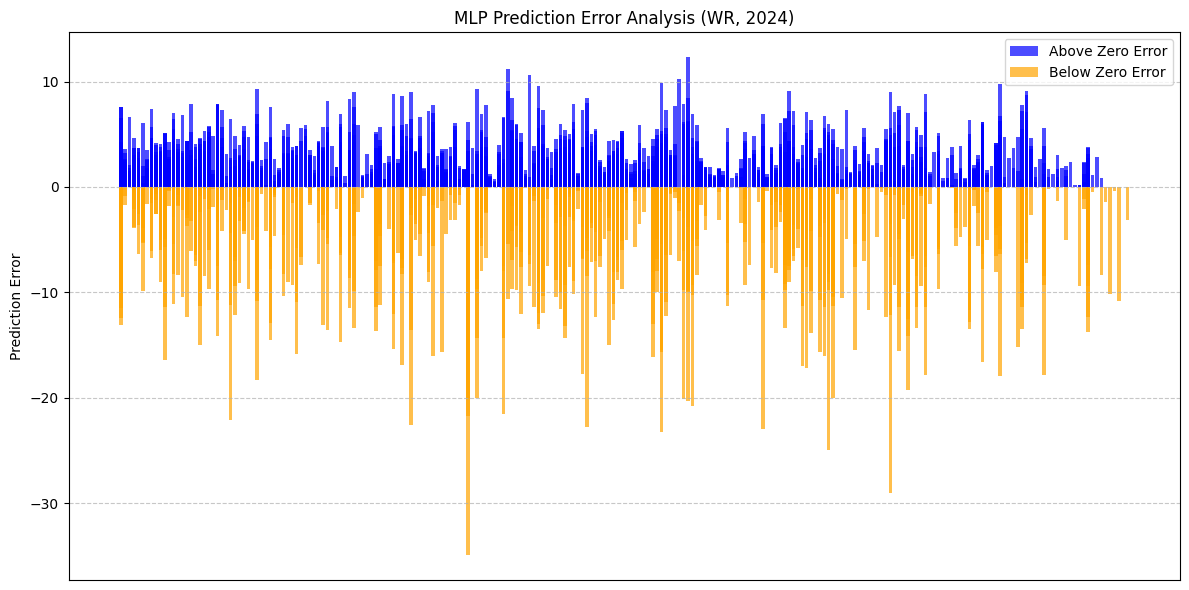

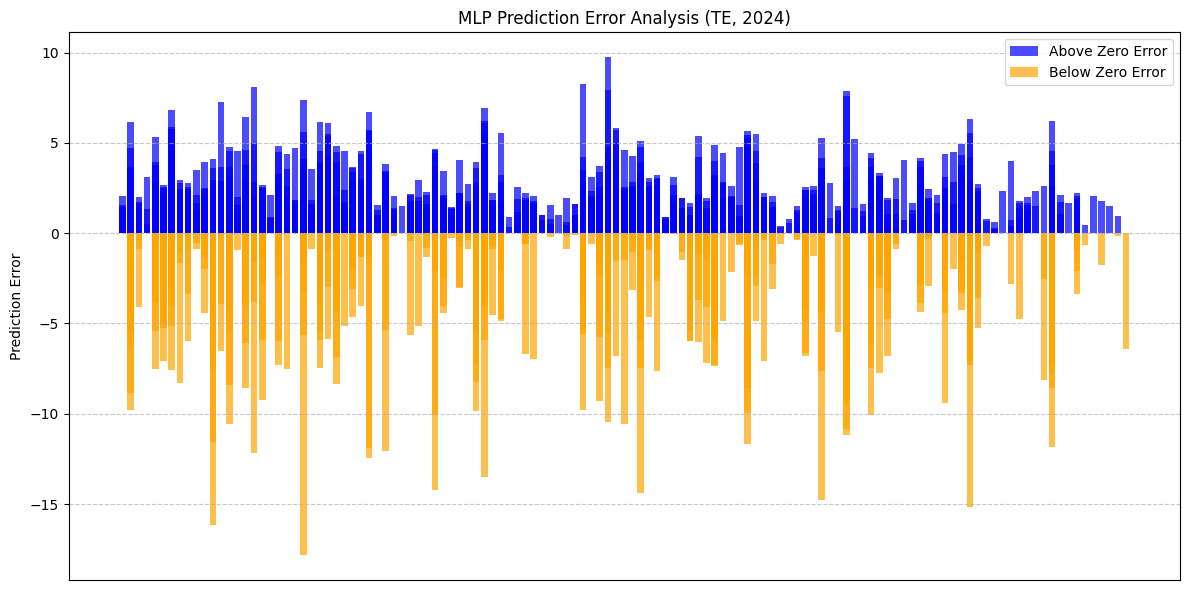

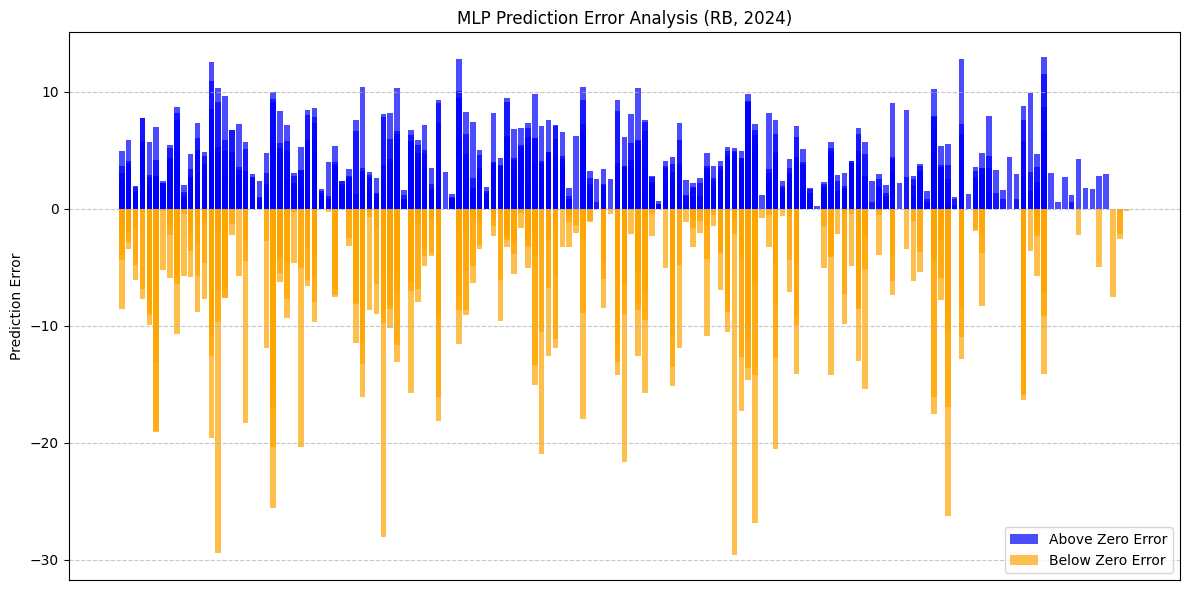

In [ ]:
position_groups = predicted_fantasy_points['position_group'].unique()

# Function for Prediction error analysis
def analyze_prediction_errors(predicted_fantasy_points, position_group, season=2024):
    predicted_fantasy_points = predicted_fantasy_points.copy()
    # 2024 season only
    predicted_fantasy_points = predicted_fantasy_points[predicted_fantasy_points['season'] == season]
    # Filter by position_group
    predicted_fantasy_points = predicted_fantasy_points[predicted_fantasy_points['position_group'] == position_group]
    predicted_fantasy_points['prediction_error'] = predicted_fantasy_points['predicted_fantasy_points'] - predicted_fantasy_points['fantasy_points']

    # Convert prediction_error to percent_error - not absolute
    predicted_fantasy_points['percent_error'] = (predicted_fantasy_points['prediction_error'] / predicted_fantasy_points['fantasy_points'])

    # Above and below zero errors
    above_zero = predicted_fantasy_points[predicted_fantasy_points['prediction_error'] >= 0]
    below_zero = predicted_fantasy_points[predicted_fantasy_points['prediction_error'] < 0]

    plt.figure(figsize=(12, 6))

    # Plot above 0 error chart with blue color and alpha 0.7
    plt.bar(above_zero['player_name'], above_zero['prediction_error'], color='blue', alpha=0.7, label='Above Zero Error')
    # Plot below 0 error chart with orange color and alpha 0.7
    plt.bar(below_zero['player_name'], below_zero['prediction_error'], color='orange', alpha=0.7, label='Below Zero Error')
    # All vertical grid lines throughout the plot
    plt.grid(axis='x', linestyle='--', alpha=0.9)
    # All horizontal grid lines throughout the plot
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Remove X axis labels
    plt.xticks([])
    
    # plt.xlabel('Player Name')
    plt.ylabel('Prediction Error')
    plt.title(f'MLP Prediction Error Analysis ({position_group}, 2024)')
    # plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(f'prediction_error_analysis_{position_group}_{season}.png')
    plt.close()

# Cycle through all position groups
for position_group in position_groups:
    analyze_prediction_errors(predicted_fantasy_points, position_group)

In [ ]:
# Failure Analysis - show worst predictions by absolute value of prediction error for each position group regardless season (minimum of 5 fantasy points)
def failure_analysis(predicted_fantasy_points, top_n=1):
    predicted_fantasy_points = predicted_fantasy_points.copy()
    # Filter for minimum fantasy points of 5
    predicted_fantasy_points = predicted_fantasy_points[predicted_fantasy_points['fantasy_points'] >= 5]
    predicted_fantasy_points['prediction_error'] = predicted_fantasy_points['predicted_fantasy_points'] - predicted_fantasy_points['fantasy_points']
    predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['prediction_error'].abs()
    
    # Group by position_group and get top N worst predictions for each group
    worst_predictions = predicted_fantasy_points.groupby('position_group').apply(lambda x: x.nlargest(top_n, 'absolute_error')).reset_index(drop=True)
    
    return worst_predictions[['player_id', 'player_name', 'position_group', 'team', 'season', 'week', 'fantasy_points', 'predicted_fantasy_points', 'absolute_error']]

worst_predictions = failure_analysis(predicted_fantasy_points, top_n=1)
worst_predictions

,player_id,player_name,position_group,team,season,week,fantasy_points,predicted_fantasy_points,absolute_error
0,00-0034857,J.Allen,QB,BUF,2024,14,51.88,16.945379,34.934621
1,00-0039040,D.Achane,RB,MIA,2023,3,47.30,2.458790,44.841210
2,00-0033357,T.Hill,TE,NO,2022,5,34.08,4.798372,29.281628
3,00-0036900,J.Chase,WR,CIN,2021,17,44.60,8.036815,36.563185


In [ ]:
# # Visualize the worst predictions
# def visualize_worst_predictions(worst_predictions):
#     position_groups = worst_predictions['position_group'].unique()
#     for position_group in position_groups:
#         group_data = worst_predictions[worst_predictions['position_group'] == position_group]
#         fig, ax = plt.subplots(figsize=(4, 6))
#         x = np.arange(len(group_data))
#         width = 0.35
        
#         bars1 = ax.bar(x - width/2, group_data['absolute_error'], width, color='red', alpha=0.7, label='Absolute Error')
#         bars2 = ax.bar(x + width/2, group_data['fantasy_points'], width, color='blue', alpha=0.7, label='Fantasy Points')
        
#         # ax.set_xlabel('Player Name')
#         ax.set_ylabel('Value')
#         ax.set_title(f'Worst Predictions for {position_group}')
#         # subtitle in small font below the main title that is 'team', 'season', 'week'
#         plt.text(0.5, -0.07, f"Team: {group_data['team'].values[0]}, Season: {group_data['season'].values[0]}, Week: {group_data['week'].values[0]}", ha='center', va='center', transform=ax.transAxes, fontsize=10)
#         # plt.suptitle(f'Worst Predictions for {position_group}', fontsize=10)
#         ax.set_xticks(x)
#         ax.set_xticklabels(group_data['player_name'], rotation=0)
#         ax.grid(axis='y', linestyle='--', alpha=0.7)
#         ax.legend()
        
#         # Annotate bars with values
#         for bar in bars1:
#             height = bar.get_height()
#             ax.annotate(f'{height:.2f}',
#                          xy=(bar.get_x() + bar.get_width() / 2, height),
#                          xytext=(0, 3),
#                          textcoords="offset points",
#                          ha='center', va='bottom')
#         for bar in bars2:
#             height = bar.get_height()
#             ax.annotate(f'{height:.2f}',
#                          xy=(bar.get_x() + bar.get_width() / 2, height),
#                          xytext=(0, 3),
#                          textcoords="offset points",
#                          ha='center', va='bottom')
        
#         plt.tight_layout()
#         plt.show()
#         plt.savefig(f'worst_predictions_{position_group}.png')
#         plt.close()
        
# visualize_worst_predictions(worst_predictions)

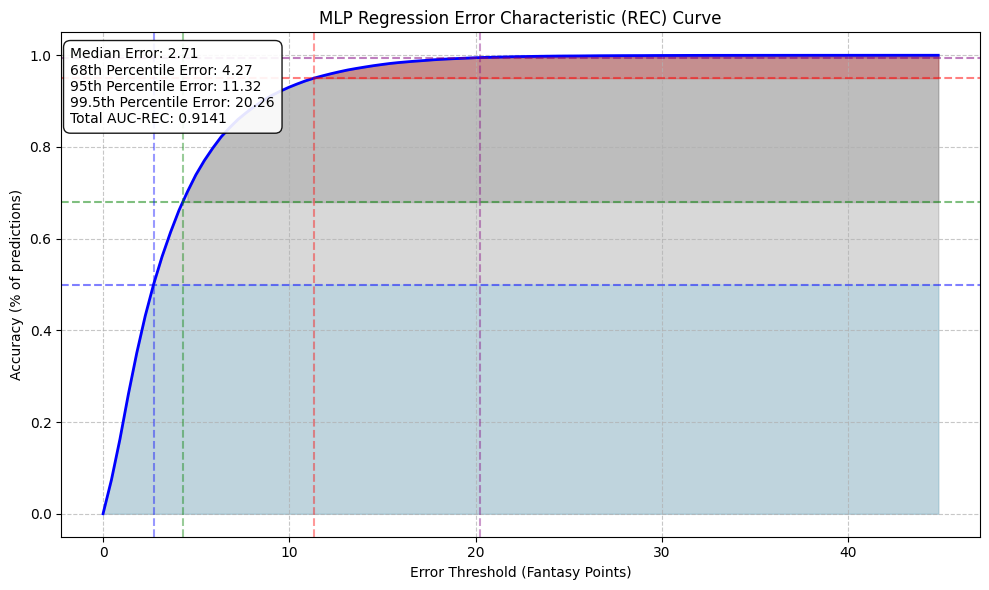

99.5th Percentile Error: 20.26 fantasy points
95th Percentile Error: 11.32 fantasy points
68th Percentile Error: 4.27 fantasy points
Median Error: 2.71 fantasy points
Total AUC-REC: 0.9141


In [ ]:
# Function for Regression Error Characteristic (REC) Curves
def plot_rec_curve(predicted_fantasy_points):
    predicted_fantasy_points = predicted_fantasy_points.copy()
    
    # Calculate the absolute errors
    predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['predicted_fantasy_points'] - predicted_fantasy_points['fantasy_points']
    predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['absolute_error'].abs()
    
    # Calculate absolute errors
    errors = predicted_fantasy_points['absolute_error'].values
    
    # Create threshold values from 0 to max error
    thresholds = np.linspace(0, max(errors), 100)
    
    # Calculate accuracy for each threshold
    accuracies = [np.mean(errors <= threshold) for threshold in thresholds]
    
    # Plot REC curve
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, accuracies, 'b-', linewidth=2)
    plt.xlabel('Error Threshold (Fantasy Points)')
    plt.ylabel('Accuracy (% of predictions)')
    plt.title('MLP Regression Error Characteristic (REC) Curve')
    
    # Fill area under the curve
    plt.fill_between(thresholds, np.zeros_like(thresholds), accuracies, alpha=0.3, color='grey')
    
    # Fill 99.5th Percentile Error with different color
    percentile_99_5 = np.percentile(errors, 99.5)
    accuracy_99_5 = np.mean(errors <= percentile_99_5)
    plt.axvline(x=percentile_99_5, color='purple', linestyle='--', label=f'99.5th Percentile Error: {percentile_99_5:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_99_5, color='purple', linestyle='--', label=f'99.5th Percentile Accuracy: {accuracy_99_5:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 99.5th percentile (99.5% and above)
    plt.fill_between(thresholds, accuracy_99_5, accuracies, where=(thresholds >= percentile_99_5), color='purple', alpha=0.3, label='99.5% Accuracy Region')
    
    # Fill 95th Percentile Error with different color
    percentile_95 = np.percentile(errors, 95)
    accuracy_95 = np.mean(errors <= percentile_95)
    plt.axvline(x=percentile_95, color='red', linestyle='--', label=f'95th Percentile Error: {percentile_95:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_95, color='red', linestyle='--', label=f'95th Percentile Accuracy: {accuracy_95:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 95th percentile (95% and above)
    plt.fill_between(thresholds, accuracy_95, accuracies, where=(thresholds >= percentile_95), color='red', alpha=0.3, label='95% Accuracy Region')

    # Fill 68th Percentile Error with different color
    percentile_68 = np.percentile(errors, 68)
    accuracy_68 = np.mean(errors <= percentile_68)
    plt.axvline(x=percentile_68, color='green', linestyle='--', label=f'68th Percentile Error: {percentile_68:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_68, color='green', linestyle='--', label=f'68th Percentile Accuracy: {accuracy_68:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 68th percentile (68% and above)
    plt.fill_between(thresholds, accuracy_68, accuracies, where=(thresholds >= percentile_68), color='grey', alpha=0.3, label='68% Accuracy Region')

    # Add grid
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add reference line at median error
    median_error = np.median(errors)
    plt.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5)
    plt.axvline(x=median_error, color='blue', linestyle='--', label=f'Median Error: {median_error:.2f}', alpha=0.4)
    
    # Shaded region under the curve at median error (50% and below)
    plt.fill_between(thresholds, 0, np.minimum(accuracies, 0.5), color='skyblue', alpha=0.3, label='50% Accuracy Region')
    
    # Calculate total area under the REC curve (AUC-REC)
    auc_rec = np.trapz(accuracies, thresholds) / (max(thresholds) * 1)  # Normalize by max threshold

    # Add box to upper left corner with statistics
    stats_text = f'Median Error: {median_error:.2f}\n68th Percentile Error: {percentile_68:.2f}\n95th Percentile Error: {percentile_95:.2f}\n99.5th Percentile Error: {percentile_99_5:.2f}\nTotal AUC-REC: {auc_rec:.4f}'
    plt.gca().text(0.01, 0.97, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))

    # Improve layout
    plt.tight_layout()
    plt.show()
    plt.savefig('rec_curve.png')
    plt.close()
    
    # Print some statistics
    print(f"99.5th Percentile Error: {percentile_99_5:.2f} fantasy points")
    print(f"95th Percentile Error: {percentile_95:.2f} fantasy points")
    print(f"68th Percentile Error: {percentile_68:.2f} fantasy points")
    print(f"Median Error: {median_error:.2f} fantasy points")
    print(f"Total AUC-REC: {auc_rec:.4f}")
    
plot_rec_curve(predicted_fantasy_points)